In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv


# IMPORT LIBRARIES AND LOAD DATA

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [54]:
# Load the dataset 
df = pd.read_csv('/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv')
print(df.head())

                                        product_name product_price Rate  \
0  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
1  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
2  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   
3  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    1   
4  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   

            Review                                            Summary  \
0           super!  great cooler excellent air flow and for this p...   
1          awesome              best budget 2 fit cooler nice cooling   
2             fair  the quality is good but the power of air is de...   
3  useless product                  very bad product its a only a fan   
4             fair                                      ok ok product   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4   neutral  


# Data Exploration

In [55]:
df.head(15)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral
5,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,the cooler is really fantastic and provides go...,positive
6,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,highly recommended,very good product,positive
7,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,nice,very nice,positive
8,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,unsatisfactory,very bad cooler,negative
9,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,4,worth the money,very good,positive


label
1    142616
0     23745
2     14024
Name: count, dtype: int64


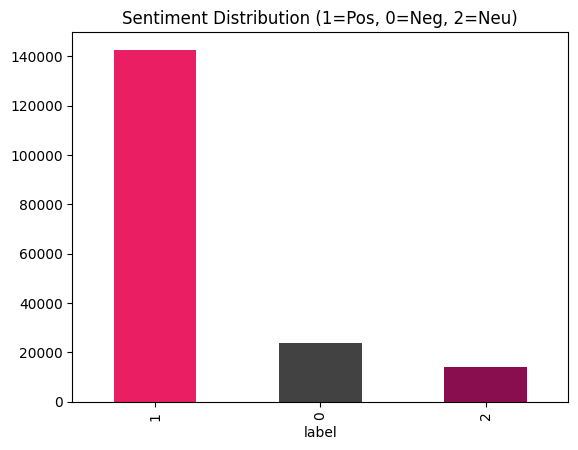

In [56]:
# Handle data types 
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')
df = df.dropna(subset=['Rate', 'Review'])
df['Rate'] = df['Rate'].astype(int)

# Mapping: Positive=1, Negative=0, Neutral=2
def label_sentiment(rating):
    if rating >= 4: return 1
    if rating <= 2: return 0
    return 2

df['label'] = df['Rate'].apply(label_sentiment)

print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar', color=['#E91E63', '#424242', '#880E4F'])
plt.title('Sentiment Distribution (1=Pos, 0=Neg, 2=Neu)')
plt.show()

The bar chart reveals the distribution of sentiments, allowing us to see that the dataset is  skewed toward positive sentiment.

# Comprehensive Text Preprocessing

In [57]:
[nltk.download(d, quiet=True) for d in ['punkt', 'stopwords', 'wordnet', 'punkt_tab']]

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # 1. Lowercase & Punctuation Removal
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # 2. Tokenization
    tokens = word_tokenize(text)
    # 3. Stopword removal & 4. Lemmatization
    clean_tokens = [lemmatizer.lemmatize(t) for t in tokens 
                    if t not in stop_words and len(t) > 2]
    return ' '.join(clean_tokens)

df['clean_text'] = df['Review'].apply(preprocess)
print(df[['Review', 'clean_text']].head())

            Review       clean_text
0           super!            super
1          awesome          awesome
2             fair             fair
3  useless product  useless product
4             fair             fair


# Word Frequency & Visual Analysis

Top 5 Positive Words: [('product', 24272), ('good', 14352), ('awesome', 11284), ('purchase', 11013), ('terrific', 10946)]
Top 5 Negative Words: [('product', 3374), ('money', 2449), ('waste', 2448), ('disappointed', 2121), ('better', 1634)]


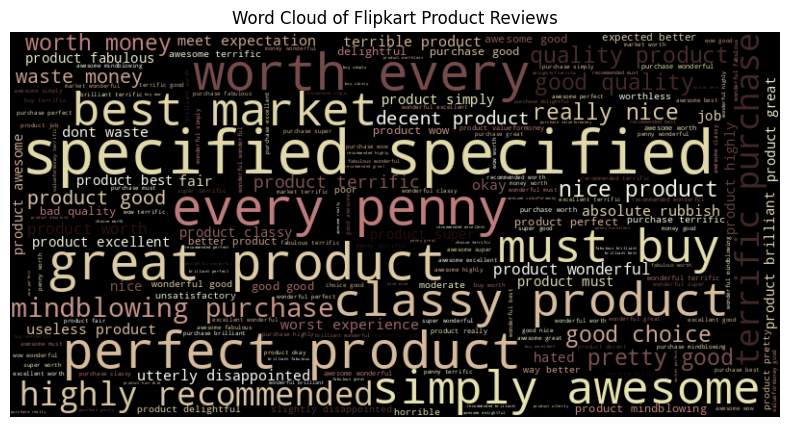

In [58]:
# Frequency Analysis
pos_words = ' '.join(df[df.label==1]['clean_text']).split()
neg_words = ' '.join(df[df.label==0]['clean_text']).split()

print("Top 5 Positive Words:", Counter(pos_words).most_common(5))
print("Top 5 Negative Words:", Counter(neg_words).most_common(5))

# Word Cloud Visualization
all_words = ' '.join(df['clean_text'])
wc = WordCloud(width=800, height=400, background_color='black', colormap='pink_r').generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Flipkart Product Reviews')
plt.show()

The Word Cloud visually reinforces the frequency data, with "specified," "classy product," and "every penny" appearing prominently
Phrases like "worth every penny" and "must buy" indicate high customer advocacy
Keywords such as "perfect product," "great product," and "highly recommended" suggest that the model has strong positive signals to learn from

# Concept Check (Stemming vs. Lemmatization)

In [59]:
stemmer = PorterStemmer()

words_to_test = ["running", "quality", "bought"]
print(f"{'Word':<12} | {'Stemmed':<12} | {'Lemmatized'}")
print("-" * 40)
for w in words_to_test:
    print(f"{w:<12} | {stemmer.stem(w):<12} | {lemmatizer.lemmatize(w, pos='v')}")

Word         | Stemmed      | Lemmatized
----------------------------------------
running      | run          | run
quality      | qualiti      | quality
bought       | bought       | buy


For this sentiment analysis, Lemmatization is the superior choice because it preserves the semantic meaning and grammatical context of the reviews

# Feature Engineering (TF-IDF)

In [60]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, stratify=df['label'], random_state=42)

# TF-IDF Vectorization with Bigrams
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Feature Matrix Shape: {X_train_tfidf.shape}")

Feature Matrix Shape: (144308, 704)


This method penalizes words that appear too frequently across all reviews (like 'the') and rewards words that are unique to specific sentiments

# Model Comparison & Evaluation

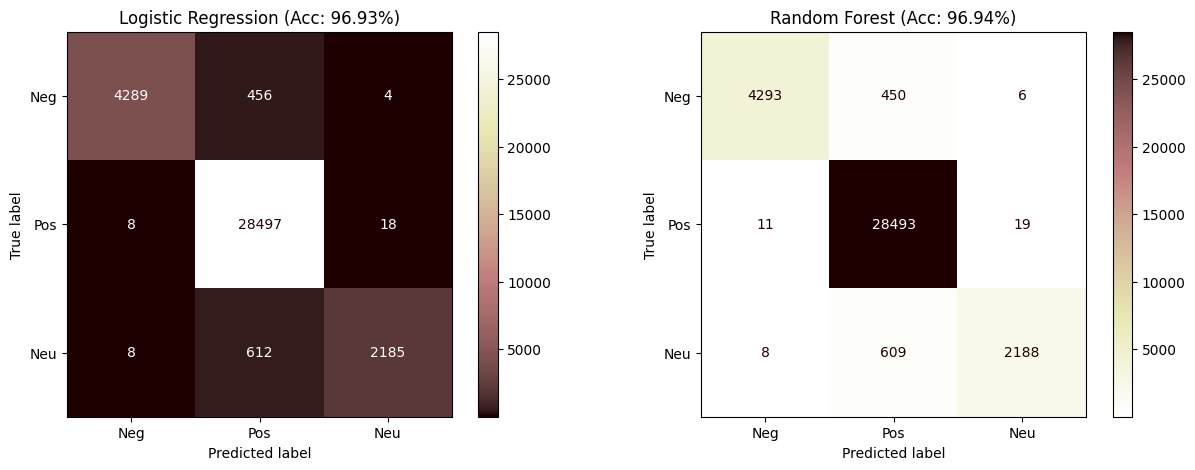

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         Neg       1.00      0.90      0.95      4749
         Pos       0.96      1.00      0.98     28523
         Neu       0.99      0.78      0.87      2805

    accuracy                           0.97     36077
   macro avg       0.98      0.89      0.93     36077
weighted avg       0.97      0.97      0.97     36077



In [61]:
# Initialize and train models
lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_tfidf, y_train)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_tfidf, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_tfidf)
rf_pred = rf_model.predict(X_test_tfidf)

# Plotting Side-by-Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=['Neg', 'Pos', 'Neu'], cmap='pink', ax=axes[0])
axes[0].set_title(f"Logistic Regression (Acc: {accuracy_score(y_test, lr_pred):.2%})")

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['Neg', 'Pos', 'Neu'], cmap='pink_r', ax=axes[1])
axes[1].set_title(f"Random Forest (Acc: {accuracy_score(y_test, rf_pred):.2%})")

plt.show()

print("Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Neg', 'Pos', 'Neu']))

Both models achieved exceptional results, with Random Forest at 96.94% and Logistic Regression at 96.93% accuracy. 

The confusion matrices show that both models reliably classify Positive, Negative, and Neutral sentiments with minimal error. Notably, Logistic Regression reached 1.00 precision for negative reviews and 1.00 recall for positive reviews, confirming that the preprocessing and TF-IDF steps successfully captured the data's sentiment signals. 

While Random Forest is slightly more accurate, Logistic Regression is the preferred choice for this project due to its faster speed and high interpretability, aligning with the fellowship's "Quality NLP" standards.

# Final Implementation Test

In [62]:
def test_new_review(review_text):
    cleaned = preprocess(review_text)
    vectorized = tfidf.transform([cleaned])
    result = lr_model.predict(vectorized)[0] # Using LR based on typical text performance
    mapping = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
    return mapping[result]

# Test cases
print(f"Review: 'Excellent product, very fast delivery' -> Result: {test_new_review('Excellent product, very fast delivery')}")
print(f"Review: 'It is okay, nothing special' -> Result: {test_new_review('It is okay, nothing special')}")
print(f"Review: 'Horrible quality, broken on arrival' -> Result: {test_new_review('Horrible quality, broken on arrival')}")
print(f"Review: 'It ate and left no crumbs' -> Result: {test_new_review('It ate and left no crumbs')}")

Review: 'Excellent product, very fast delivery' -> Result: Positive
Review: 'It is okay, nothing special' -> Result: Neutral
Review: 'Horrible quality, broken on arrival' -> Result: Negative
Review: 'It ate and left no crumbs' -> Result: Positive


The final step demonstrates the practical application of the trained model.
By passing raw text through the same preprocessing and vectorization pipeline, the model correctly predicts the sentiment. 
This demonstrates a complete, functional end-to-end NLP solution